# Fine-tune PhoBERT cho bài toán Phân loại Khiếu nại

Notebook này fine-tune mô hình PhoBERT (`vinai/phobert-base-v2`) cho bài toán phân loại văn bản nhị phân: 0 = Bình thường, 1 = Khiếu nại.

**Dữ liệu:** `data/processed/shopee_mapped.csv`  
**Tiền xử lý:** `clean_vietnamese_text` từ `src.utils.utils`  
**Huấn luyện:** Hugging Face `Trainer`

## Bước 1: Cài đặt và Import thư viện

In [ ]:
# Cell 1: Cài đặt thư viện cần thiết cho Colab
# Nếu chạy trên Colab, hãy bật cell này trước khi huấn luyện
!pip -q install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/vngbthang/ie403-Ecom-MultiTask-Complaint-Detection

Cloning into 'ie403-Ecom-MultiTask-Complaint-Detection'...
remote: Enumerating objects: 16573, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16573 (delta 5), reused 14 (delta 3), pack-reused 16556 (from 2)
Receiving objects: 100% (16573/16573), 132.68 MiB | 6.29 MiB/s, done.
Resolving deltas: 100% (3198/3198), done.


In [ ]:
ls

ie403-Ecom-MultiTask-Complaint-Detection/  sample_data/


In [ ]:
cd ie403-Ecom-MultiTask-Complaint-Detection/

/content/ie403-Ecom-MultiTask-Complaint-Detection


In [ ]:
ls

bio_annotation_tool_A.py  data/                 requirements.txt
bio_annotation_tool_B.py  docs/                 src/
bio_annotation_tool_C.py  merge_annotations.py  TEAM_ANNOTATION_GUIDE.md
bio_annotation_tool_D.py  notebooks/
bio_annotation_tool.py    README.md


## Bước 2: Tải, làm sạch và chia dữ liệu

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

# Thêm đường dẫn gốc để import hàm clean_vietnamese_text
ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from src.utils.utils import clean_vietnamese_text

# Thiết lập seed để kết quả ổn định
set_seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Cấu hình device (Trainer sẽ tự dùng GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[OK] Device hiện tại: {device}')
print(f'[INFO] Root directory: {ROOT_DIR}')

[OK] Device hiện tại: cpu
[INFO] Root directory: /content


In [ ]:
# Đọc dữ liệu gốc
csv_path = os.path.join('data', 'processed', 'shopee_mapped.csv')
df = pd.read_csv(csv_path, encoding='utf-8-sig')
print(f'[INFO] Số dòng ban đầu: {len(df)}')

# Xóa các dòng NaN ở cột review
before_na = df['review'].isna().sum()
df = df.dropna(subset=['review']).reset_index(drop=True)
print(f'[INFO] Số NaN ở cột review trước khi xóa: {before_na}')
print(f'[OK] Số dòng còn lại sau khi xóa NaN: {len(df)}')

# Làm sạch văn bản
df['cleaned_text'] = df['review'].astype(str).apply(clean_vietnamese_text)
print('[OK] Đã tạo cột cleaned_text')

# Chia train/test theo stratify
train_df, eval_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['complaint_label']
)

print(f'[INFO] Kích thước train_df: {len(train_df)}')
print(f'[INFO] Kích thước eval_df: {len(eval_df)}')
print('[INFO] Phân phối nhãn train:')
print(train_df['complaint_label'].value_counts(normalize=True))
print('[INFO] Phân phối nhãn eval:')
print(eval_df['complaint_label'].value_counts(normalize=True))

# Chuyển sang Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'complaint_label']].rename(columns={'cleaned_text': 'text'}).reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df[['cleaned_text', 'complaint_label']].rename(columns={'cleaned_text': 'text'}).reset_index(drop=True))
print('[OK] Đã chuyển DataFrame sang Hugging Face Dataset')

[INFO] Số dòng ban đầu: 7817
[INFO] Số NaN ở cột review trước khi xóa: 0
[OK] Số dòng còn lại sau khi xóa NaN: 7817
[OK] Đã tạo cột cleaned_text
[INFO] Kích thước train_df: 6253
[INFO] Kích thước eval_df: 1564
[INFO] Phân phối nhãn train:
complaint_label
1    0.537502
0    0.462498
Name: proportion, dtype: float64
[INFO] Phân phối nhãn eval:
complaint_label
1    0.537724
0    0.462276
Name: proportion, dtype: float64
[OK] Đã chuyển DataFrame sang Hugging Face Dataset


## Bước 3: Tokenization với PhoBERT

In [ ]:
# Load tokenizer PhoBERT
model_name = 'vinai/phobert-base-v2'
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
print(f'[OK] Đã load tokenizer: {model_name}')

# Hàm tokenize cho Hugging Face Dataset
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128,
    )

# Tokenize dataset và đổi tên cột nhãn thành labels
train_dataset = train_dataset.rename_column('complaint_label', 'labels')
eval_dataset = eval_dataset.rename_column('complaint_label', 'labels')

train_dataset = train_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.map(tokenize_function, batched=True)

# Loại bỏ các cột không cần thiết cho Trainer
train_dataset = train_dataset.remove_columns(['text'])
eval_dataset = eval_dataset.remove_columns(['text'])

print('[OK] Tokenization hoàn tất')
print(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[OK] Đã load tokenizer: vinai/phobert-base-v2


Map:   0%|          | 0/6253 [00:00<?, ? examples/s]

Map:   0%|          | 0/1564 [00:00<?, ? examples/s]

[OK] Tokenization hoàn tất
{'labels': 0, 'input_ids': [0, 819, 284, 156, 294, 567, 9534, 26427, 1850, 4, 574, 119, 485, 19640, 287, 4770, 40672, 1387, 4, 3852, 3802, 32, 11, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


## Bước 4: Định nghĩa mô hình và hàm tính metric

In [ ]:
# Load PhoBERT cho bài toán sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)
print('[OK] Đã load model PhoBERT cho classification')

# Hàm tính metric theo yêu cầu

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='macro',
        zero_division=0,
    )

    return {
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }

print('[OK] Đã định nghĩa hàm compute_metrics')

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[OK] Đã load model PhoBERT cho classification
[OK] Đã định nghĩa hàm compute_metrics


## Bước 5: Cấu hình và huấn luyện bằng Trainer

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

# Thêm đường dẫn gốc để import hàm clean_vietnamese_text
ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from src.utils.utils import clean_vietnamese_text

# Thiết lập seed để kết quả ổn định
set_seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Cấu hình device (Trainer sẽ tự dùng GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[OK] Device hiện tại: {device}')
print(f'[INFO] Root directory: {ROOT_DIR}')

# Cấu hình arguments cho Trainer
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy='epoch', # Changed from evaluation_strategy
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none',
)

# Data collator để đảm bảo batch padding đúng chuẩn
# Dù đã padding='max_length', collator vẫn an toàn cho Trainer

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('[OK] Đã khởi tạo Trainer')
print(training_args)

[OK] Device hiện tại: cpu
[INFO] Root directory: /content
[OK] Đã khởi tạo Trainer
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,

In [ ]:
# Huấn luyện mô hình
print('[INFO] Bắt đầu fine-tune PhoBERT...')
trainer.train()
print('[OK] Hoàn tất huấn luyện')

[INFO] Bắt đầu fine-tune PhoBERT...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.174818,0.153065,0.951407,0.953906,0.949188,0.950906
2,0.114406,0.159152,0.946931,0.946170,0.948228,0.946774
3,0.090251,0.152999,0.951407,0.950668,0.952002,0.951207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

[OK] Hoàn tất huấn luyện


## Bước 6: Đánh giá và trực quan hóa

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



CLASSIFICATION REPORT - PhoBERT
                 precision    recall  f1-score   support

Bình thường (0)       0.94      0.96      0.95       723
  Khiếu nại (1)       0.96      0.94      0.95       841

       accuracy                           0.95      1564
      macro avg       0.95      0.95      0.95      1564
   weighted avg       0.95      0.95      0.95      1564

[INFO] Accuracy: 0.9514


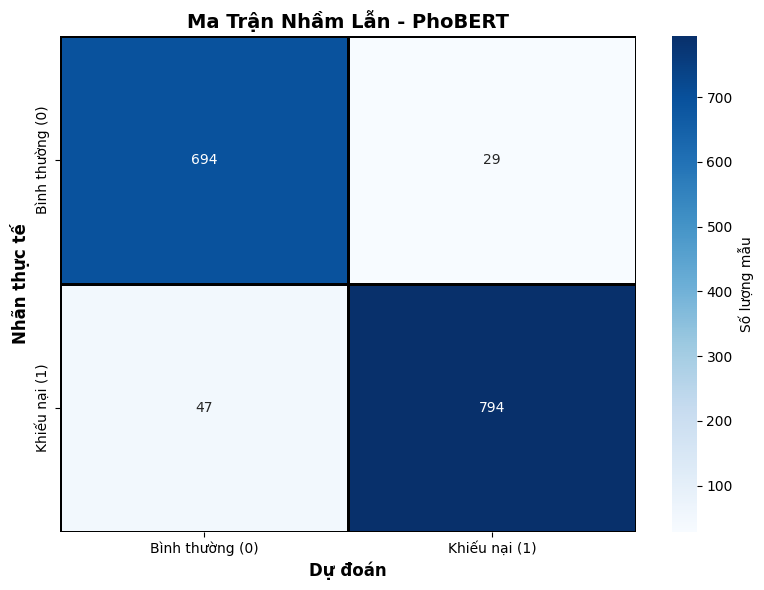

[OK] Đã lưu confusion matrix tại data/processed/phobert_confusion_matrix.png


In [ ]:
# Dự đoán trên tập eval
pred_output = trainer.predict(eval_dataset)
pred_logits = pred_output.predictions
pred_labels = np.argmax(pred_logits, axis=-1)
true_labels = pred_output.label_ids

# Classification report
print('\n' + '=' * 80)
print('CLASSIFICATION REPORT - PhoBERT')
print('=' * 80)
print(classification_report(true_labels, pred_labels, target_names=['Bình thường (0)', 'Khiếu nại (1)']))
print('=' * 80)

# Accuracy tổng thể
acc = accuracy_score(true_labels, pred_labels)
print(f'[INFO] Accuracy: {acc:.4f}')

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bình thường (0)', 'Khiếu nại (1)'],
    yticklabels=['Bình thường (0)', 'Khiếu nại (1)'],
    linewidths=2,
    linecolor='black',
    cbar_kws={'label': 'Số lượng mẫu'}
)
plt.title('Ma Trận Nhầm Lẫn - PhoBERT', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn thực tế', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/phobert_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('[OK] Đã lưu confusion matrix tại data/processed/phobert_confusion_matrix.png')

In [ ]:
plt.savefig('data/processed/phobert_confusion_matrix.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
!cd .. && zip -r project.zip ie403-Ecom-MultiTask-Complaint-Detection

In [ ]:
from google.colab import files
files.download('/content/project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>